## IMPORTS

In [ ]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

import random

MARKOV_STEPS = 10_000
DESIRED_TCP = 0.348

## PROCESSING DATA

In [76]:
vtds = gpd.read_file("oh_2020/oh_2020.shp")
cois = gpd.read_file("Ohio/shapefile_summary/OH_20211007_phaseC_summary/OH_20211007_phaseC_summary.shp")

subclusters = cois[cois['cluster'].str.contains('-')]
parents_to_drop = subclusters['cluster'].apply(lambda x: x.split('-')[0]).unique()
cois = cois[~cois['cluster'].isin(parents_to_drop)]

if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

pres_cols = ['G20PREDBID', 'G20PRERTRU',  'G20PRELJOR', 'G20PREGHAW']
vtds['TOTPOP'] = vtds[pres_cols].sum(axis=1)

vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['cluster']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk


vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]

## OHIO 2022 ENACTED MAP

In [77]:

congressional_2022 = gpd.read_file('dir2022-27-01-congressionaldistrictshapefiles-2022-03-02/March_2nd_CD_SHPs.shp')

congressional_2022 = congressional_2022.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2022 = gpd.sjoin(vtd_points, congressional_2022, how="left", predicate="intersects")


vtds['district_2022'] = joined_vtds_2022['DISTRICT']

## HELPER FUNCTIONS

In [78]:
def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)

def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='tab20b',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

def plot_partition_party(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    district_colors = {}
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            dem_pop += partition.graph.nodes[node_id]['G20PREDBID']
            tot_pop += partition.graph.nodes[node_id]['TOTPOP']
            
        if tot_pop > 0 and (dem_pop / tot_pop) > 0.5:
            district_colors[district_id] = "lightblue"
        else:
            district_colors[district_id] = "lightcoral"
            

    vtds['party_color'] = vtds['district'].map(district_colors)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

## COUNTING FUNCTIONS

In [79]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1
    return dem_wins

def count_rep_wins(partition):
    rep_wins = 0
    for district_id, node_ids in partition.parts.items():
        rep_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            rep_pop += node_attrs['G20PRERTRU']
            tot_pop += node_attrs['TOTPOP']
            
        if rep_pop / tot_pop > 0.5:
            rep_wins += 1

    return rep_wins


def dem_share(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        dem_share = dem_pop / tot_pop if tot_pop > 0 else 0
        dem_shares.append(dem_share)
        
    dem_shares.sort()
    return tuple(dem_shares)


In [80]:
def optimized_tcp(partition):
    # favors maps preserved above the average amount, should see dem favor
    tcp_score = partition['tcp_score']
    chance = random.random()

    if tcp_score > DESIRED_TCP:
        return chance > 0.2
    else:
        return chance < 0.2  

def unoptimized_tcp(partition):
    # favors badly preserved maps, should see republican favor
    tcp_score = partition['tcp_score']
    chance = random.random()

    if tcp_score > DESIRED_TCP:
        return chance < 0.2
    else:
        return chance > 0.2   

## INIT GRAPH AND CHAIN

In [81]:
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# ohio has 15 districts(in 2020 they now how 15)
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 15

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(15), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'rep_wins': count_rep_wins,
        'dem_share': dem_share
    }
)


#plot_partition(initial_partition, vtds, cois, 'Initial Map')

## init chain
proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps= MARKOV_STEPS
)

c:\Users\noede\OneDrive\Desktop\CS\MCURE\.venv\Lib\site-packages\gerrychain\graph\adjacency.py:112: UserWarning: Found overlaps among the given polygons. Indices of overlaps: {(8730, 8731), (8832, 8835), (7355, 8922), (8764, 8766), (8832, 8834), (8765, 8766)}
  warnings.warn(


In [ ]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []
rep_wins_count = []


# dem shares init
dist_1_shares = []
dist_2_shares = []
dist_3_shares = []
dist_4_shares = []
dist_5_shares = []
dist_6_shares = []
dist_7_shares = []
dist_8_shares = []
dist_9_shares = []
dist_10_shares = []
dist_11_shares = []
dist_12_shares = []
dist_13_shares = []
dist_14_shares = []
dist_15_shares = []

best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

tcp_scores_by_seats = {seat_count: [] for seat_count in range(16)}

for partition in chain:

    if len(tcp_scores) > 0 and len(tcp_scores) % 50000 == 0:
        print(f"completed {len(tcp_scores)} steps...")

    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    rep_seats = partition['rep_wins']
    shares = partition['dem_share']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)
    rep_wins_count.append(rep_seats)


    dist_1_shares.append(shares[0])
    dist_2_shares.append(shares[1])
    dist_3_shares.append(shares[2])
    dist_4_shares.append(shares[3])
    dist_5_shares.append(shares[4])
    dist_6_shares.append(shares[5])
    dist_7_shares.append(shares[6])
    dist_8_shares.append(shares[7])
    dist_9_shares.append(shares[8])
    dist_10_shares.append(shares[9])
    dist_11_shares.append(shares[10])
    dist_12_shares.append(shares[11])
    dist_13_shares.append(shares[12])
    dist_14_shares.append(shares[13])
    dist_15_shares.append(shares[14])


    # append scores under its seat count 
    tcp_scores_by_seats[seats].append(score)

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition
        
    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# save to csv

chain_results = {
    'step': range(len(tcp_scores)), # Automatically numbers your steps 0 to 9999
    'tcp_score': tcp_scores,
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'dist_1_dem_share': dist_1_shares,
    'dist_2_dem_share': dist_2_shares,
    'dist_3_dem_share': dist_3_shares,
    'dist_4_dem_share': dist_4_shares,
    'dist_5_dem_share': dist_5_shares,
    'dist_6_dem_share': dist_6_shares,
    'dist_7_dem_share': dist_7_shares,
    'dist_8_dem_share': dist_8_shares,
    'dist_9_dem_share': dist_9_shares,
    'dist_10_dem_share': dist_10_shares,
    'dist_11_dem_share': dist_11_shares,
    'dist_12_dem_share': dist_12_shares,
    'dist_13_dem_share': dist_13_shares,
    'dist_14_dem_share': dist_14_shares,
    'dist_15_dem_share': dist_15_shares

}

results_df = pd.DataFrame(chain_results)
results_df.to_csv("ohio_100k_chain_results.csv", index=False)



In [83]:
enacted_2022 = Partition(
    g,
    assignment="district_2022",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins
    }
)

## HISTOGRAMS

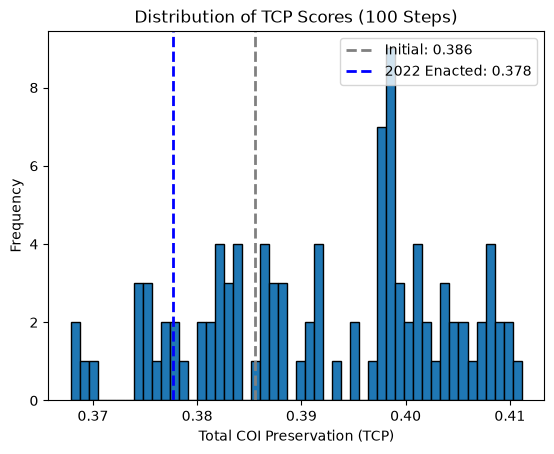

In [84]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
score_2022 = enacted_2022["tcp_score"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2022,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: {score_2022:.3f}",
)

plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

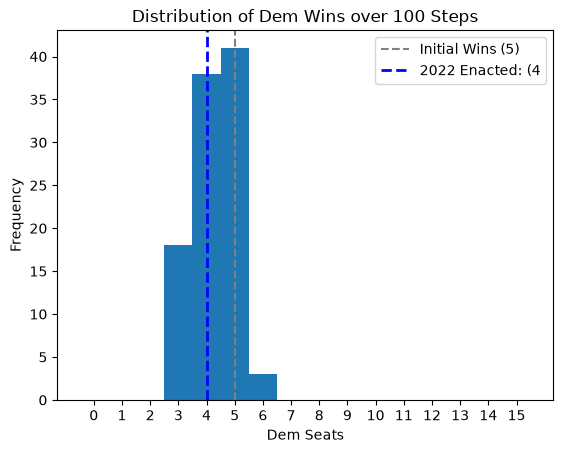

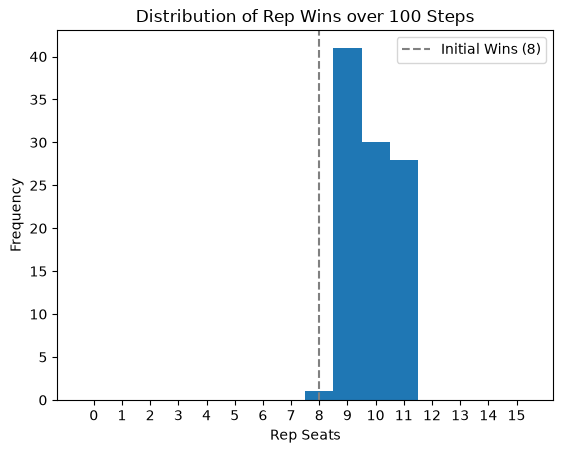

In [85]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2022 = count_dem_wins(enacted_2022)


plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x = wins_2022,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2022}",
)


plt.legend()
plt.show()


plt.hist(
    rep_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Rep Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Rep Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_rep_wins(initial_partition)


plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')


plt.legend()
plt.show()

## BOX PLOTS

[3, 4, 5, 6]


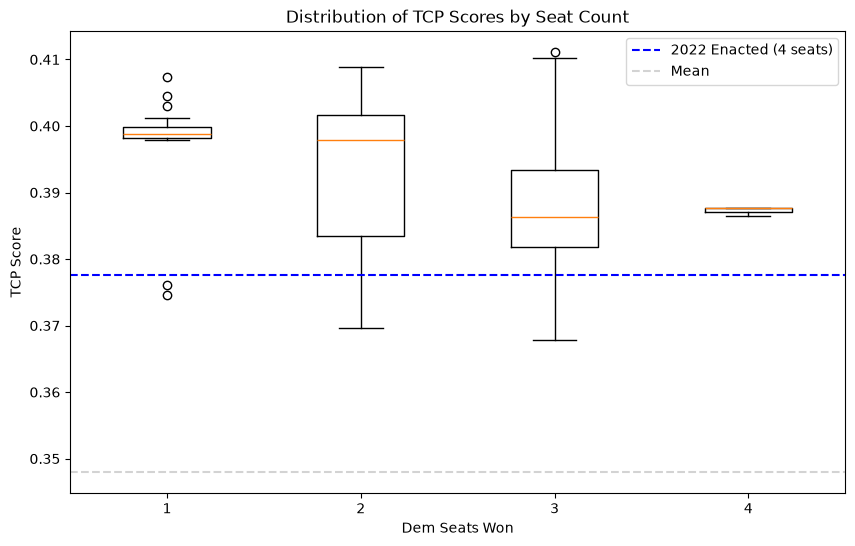

In [86]:

seats_with_data = [s for s in range(16) if len(tcp_scores_by_seats[s]) > 0]
print(seats_with_data)
data_to_plot = [tcp_scores_by_seats[s] for s in seats_with_data]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot)
plt.axhline(score_2022, color="blue", linestyle="dashed", label=f"2022 Enacted ({wins_2022} seats)")
plt.axhline(DESIRED_TCP, color="lightgrey", linestyle="dashed", label="Mean")
plt.xticks()
plt.xlabel("Dem Seats Won")
plt.ylabel("TCP Score")
plt.title("Distribution of TCP Scores by Seat Count")
plt.legend()
plt.show()

## OHIO COI MAP

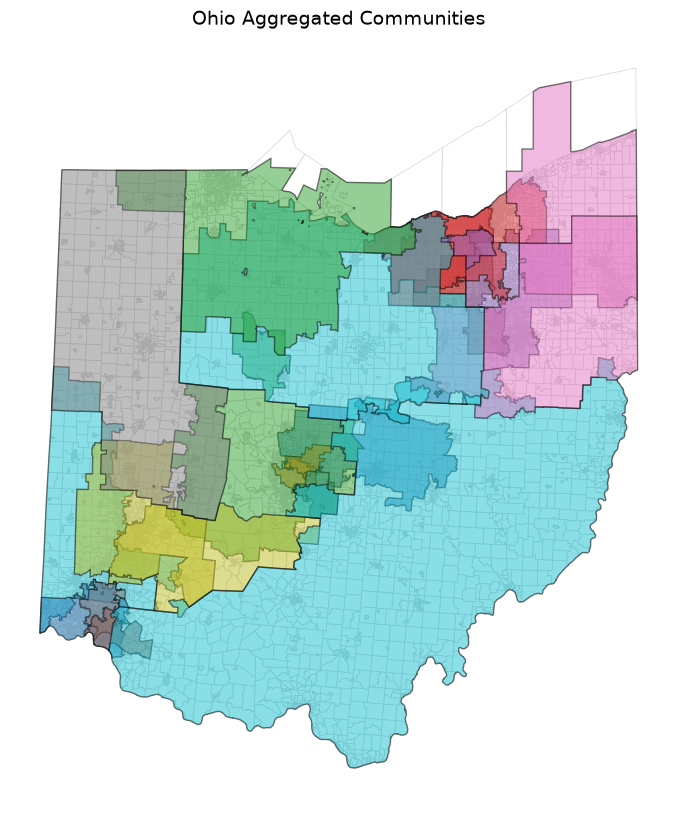

In [87]:
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, column="cluster", alpha=0.5, edgecolor="black")

ax.set_title("Ohio Aggregated Communities", fontsize=14)
ax.axis("off")
plt.show()

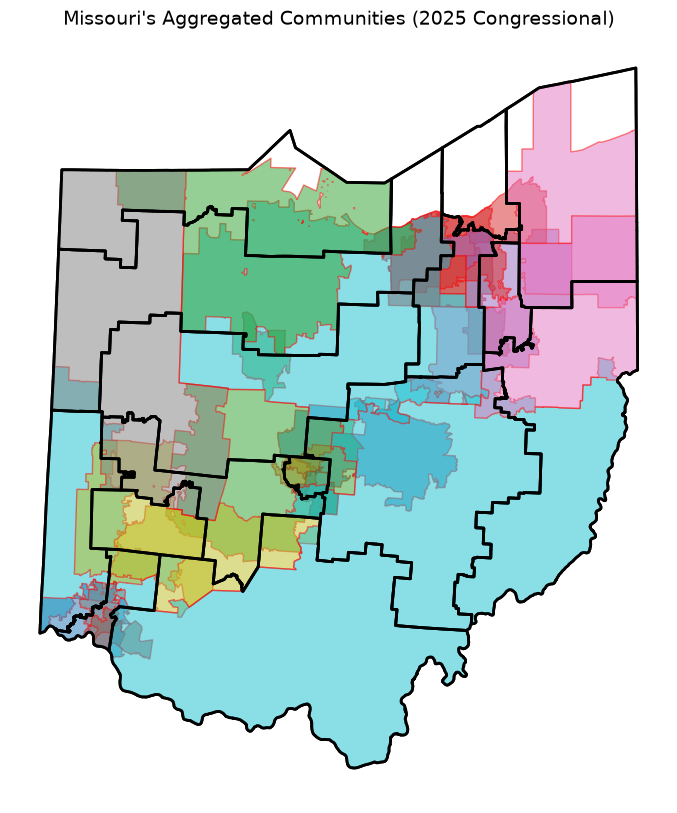

In [88]:
fig, ax = plt.subplots(figsize=(12, 10))

congressional_2022.plot(ax=ax, edgecolor='black', color='white',linewidth=2)
cois.plot(ax=ax, column="cluster",edgecolor="red", alpha=0.5)
congressional_2022.plot(ax=ax, facecolor='none', linewidth=2)

ax.set_title("Missouri's Aggregated Communities (2025 Congressional)", fontsize=14)
ax.axis("off")
plt.show()

## PARTITION MAPS

plotting most preserved map:
tcp score: 0.411
cut edges: 1404
dem seats won: 5/16


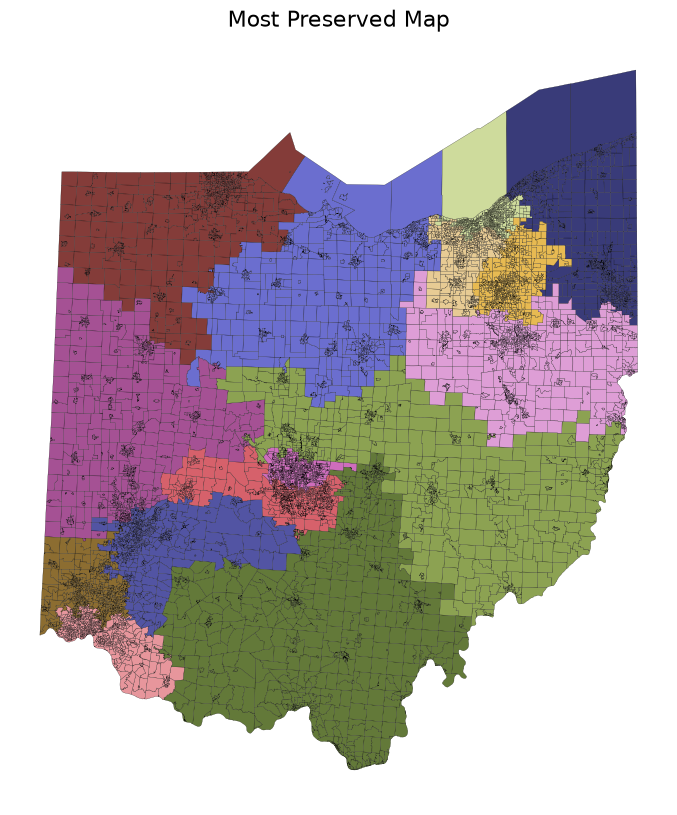

plotting least preserved map:
tcp score: 0.368
cut edges: 1693
dem seats won: 5/16


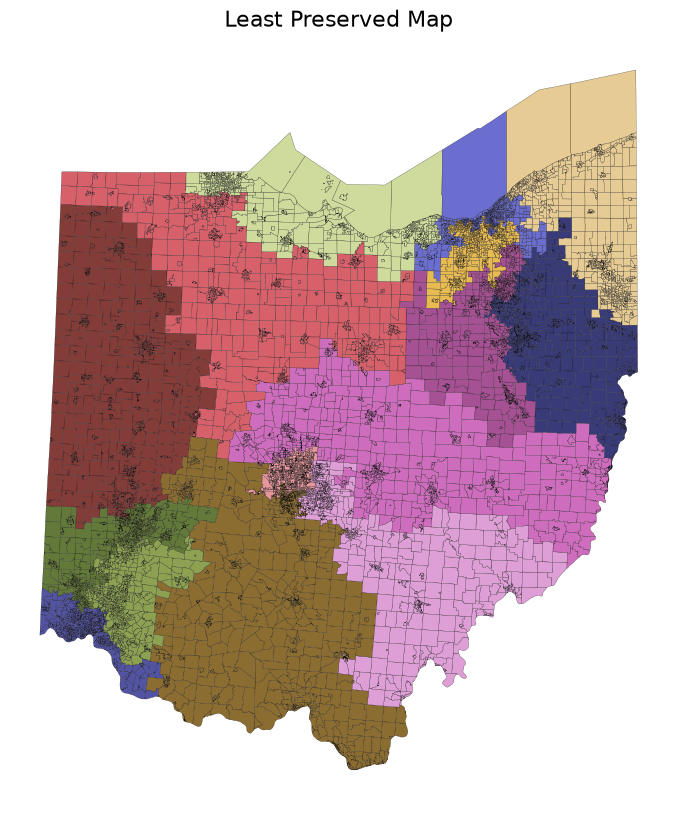

plotting best max representation map:
tcp score: 0.388
cut edges: 1623
dem seats won: 6/16


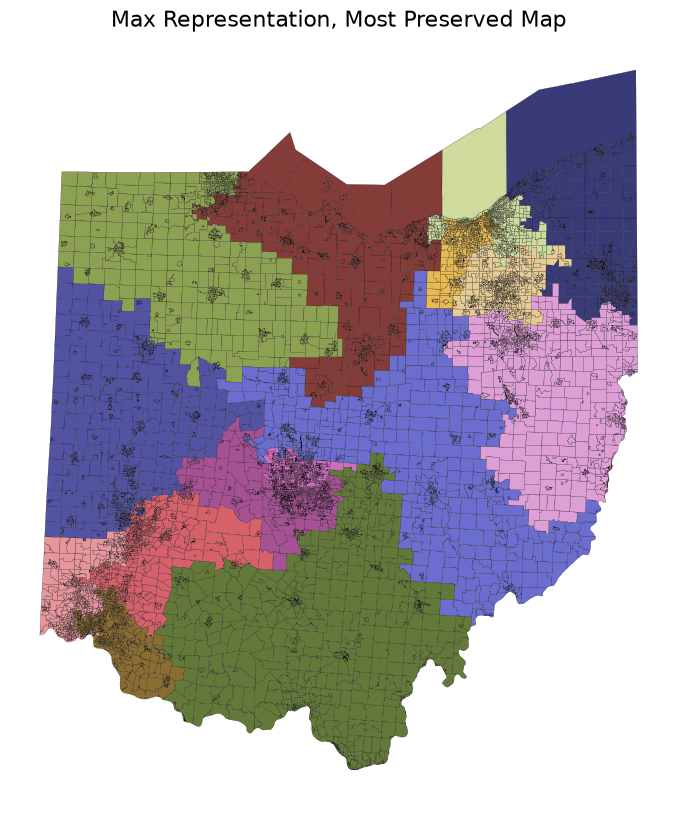

In [89]:
# plotted partition maps
print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/16")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')

print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/16")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/16")
plot_partition(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')